In [28]:
import numpy as np
import xenomorph as xm
import xenomorph.mcfost as xmc
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle

In [7]:
folder = 'rad_transfer/WR140_3.5_periastron_grid'

with open(folder + '/parameter_grid.pkl', 'rb') as inp:
    parameter_grid = pickle.load(inp)
parameter_grid

{'inclination': array([  0.        ,  10.58823529,  21.17647059,  31.76470588,
         42.35294118,  52.94117647,  63.52941176,  74.11764706,
         84.70588235,  95.29411765, 105.88235294, 116.47058824,
        127.05882353, 137.64705882, 148.23529412, 158.82352941,
        169.41176471, 180.        ])}

In [8]:
grid_array = xmc.read_lightcurve_grid(3.5, parameter_grid, method='periastron_dense', n_samples=30, root_dir=folder)

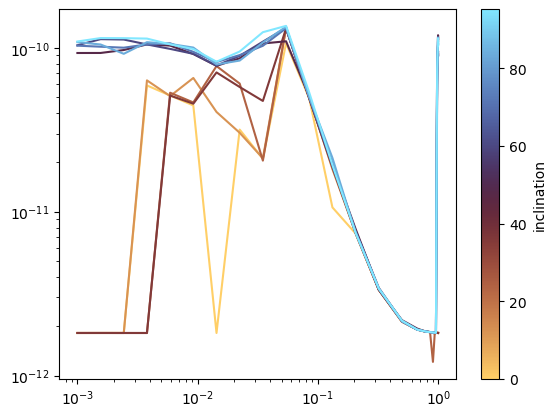

In [50]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig, ax = plt.subplots()

phases = xmc.sample_phases('periastron_dense', 30)
inclinations = parameter_grid['inclination']

n = len(inclinations) // 2

cmap_name = 'managua'

cmap = mpl.colormaps[cmap_name]
colours = cmap(np.linspace(0, 1, n))

for i in range(n):
    ax.plot(phases, grid_array[i, :], c=colours[i])
ax.set(yscale='log', xscale='log')

cmappable = ScalarMappable(Normalize(inclinations[0], inclinations[n]))
cmappable.set_cmap(cmap_name)
plt.colorbar(cmappable, ax=ax, label='inclination')